In [34]:
#install data locally

import os
os.environ["KAGGLEHUB_CACHE"] = "./data"

import kagglehub

# Download latest version
path = kagglehub.dataset_download("stevezeyuzhang/rsna-pneumonia-detection-challenge")
print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge


In [46]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
 
import keras
from keras.models import Sequential
from keras.layers import Dense, Conv2D, MaxPool2D, Flatten, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import ModelCheckpoint, EarlyStopping
from keras.optimizers import Adam
 
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')


In [47]:
# defining constants
TRAIN_IMG_DIR = "/kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge/rsna-pneumonia-detection-challenge/stage_2_train_images_png"  
CSV_PATH      = "/kaggle/input/datasets/stevezeyuzhang/rsna-pneumonia-detection-challenge/rsna-pneumonia-detection-challenge/stage_2_train_labels.csv"
IMG_SIZE      = (64, 64)
BATCH_SIZE    = 128
EPOCHS        = 100
LR            = 0.00001

In [48]:
df = pd.read_csv(CSV_PATH)
 
# one row per patient as each patient either has pneumonia or not
df = df.drop_duplicates("patientId").reset_index(drop=True)
 
# Filename to match  PNG filename
df["filename"] = df["patientId"] + ".png"
 
# Labels
df["Target"] = df["Target"].astype(str)
 
print(f"Total patients : {len(df)}")
print(f"Normal  (0)    : {(df['Target'] == '0').sum()}")
print(f"Pneumonia (1)  : {(df['Target'] == '1').sum()}")

Total patients : 26684
Normal  (0)    : 20672
Pneumonia (1)  : 6012


In [49]:

# stratify keeps the same class ratio in both splits
train_df, val_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["Target"],
    random_state=42
)
train_df = train_df.sample(frac=0.3, random_state=42)  # ADD THIS
print(f"\nTrain size : {len(train_df)}")
print(f"Val size   : {len(val_df)}")



Train size : 6404
Val size   : 5337


In [50]:
# Augmentation only on training data
trdata = ImageDataGenerator(
    rescale=1.0 / 255,
    rotation_range=10,
    zoom_range=0.1,
    horizontal_flip=True,
    shear_range=0.1,
    width_shift_range=0.1,
    height_shift_range=0.1,
)
 
# Validation: only rescale, no augmentation
tsdata = ImageDataGenerator(rescale=1.0 / 255)
 
traindata = trdata.flow_from_dataframe(
    dataframe=train_df,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=True,
)
 
testdata = tsdata.flow_from_dataframe(
    dataframe=val_df,
    directory=TRAIN_IMG_DIR,
    x_col="filename",
    y_col="Target",
    target_size=IMG_SIZE,
    class_mode="binary",
    batch_size=BATCH_SIZE,
    shuffle=False,
)
 


Found 6404 validated image filenames belonging to 2 classes.
Found 5337 validated image filenames belonging to 2 classes.


In [51]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["Target"].astype(int),
)
class_weights = {0: weights[0], 1: weights[1]}
print(f"\nClass weights: {class_weights}")
 



Class weights: {0: np.float64(0.6415547986375476), 1: np.float64(2.2661004953998583)}


In [52]:
from tensorflow.keras import mixed_precision
mixed_precision.set_global_policy('mixed_float16')  # ADD THIS
model = Sequential()
 
# Block 1
model.add(Conv2D(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=64, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 2
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=128, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 3
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=256, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 4
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Block 5
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(Conv2D(filters=512, kernel_size=(3, 3), padding="same", activation="relu"))
model.add(MaxPool2D(pool_size=(2, 2), strides=(2, 2)))
model.add(BatchNormalization())
 
# Classifier head
model.add(Flatten())
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))                        # prevent overfitting
model.add(Dense(units=4096, activation="relu"))
model.add(Dropout(0.5))
model.add(Dense(units=1, activation="sigmoid", dtype='float32')) # binary output
 
model.summary()


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_52 (Conv2D)              │ (None, 64, 64, 64)     │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_53 (Conv2D)              │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_20 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_54 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_55 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_56 (Conv2D)              │ (None, 16, 16, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 16, 16, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 8, 8, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 8, 8, 256)      │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 8, 8, 512)      │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 8, 8, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 4, 4, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 4, 4, 512)      │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_63 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_64 (Conv2D)              │ (None, 4, 4, 512)      │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_24 (MaxPooling2D) │ (None, 2, 2, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 2, 2, 512)      │         2,04

 Total params: 39,898,689 (152.20 MB)

 Trainable params: 39,895,745 (152.19 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [53]:
opt = Adam(learning_rate=LR)
model.compile(
    optimizer=opt,
    loss="binary_crossentropy",   # correct loss for binary classification
    metrics=["accuracy"]
)
 


In [54]:

from keras.callbacks import ReduceLROnPlateau

checkpoint = ModelCheckpoint(
    "/kaggle/working/vgg16_pneumonia_best.keras",
    monitor="val_loss",
    save_best_only=True,
    mode="min",
    verbose=1,
)

early = EarlyStopping(
    monitor="val_loss",
    patience=10,
    mode="min",
    verbose=1,
    restore_best_weights=True,
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=0.000001,
    verbose=1
)

In [55]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [56]:
weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1]),
    y=train_df["Target"].astype(int),
)
class_weights = {0: weights[0], 1: weights[1]}
print("Class weights:", class_weights)  # ADD THIS PRINT
hist = model.fit(
    traindata,
    steps_per_epoch=len(traindata),
    validation_data=testdata,
    validation_steps=len(testdata),
    epochs=EPOCHS,
    class_weight=class_weights,
    callbacks=[checkpoint, early, reduce_lr],

)

 


Class weights: {0: np.float64(0.6415547986375476), 1: np.float64(2.2661004953998583)}
Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.5748 - loss: 0.7540
Epoch 1: val_loss improved from None to 0.66911, saving model to /kaggle/working/vgg16_pneumonia_best.keras

Epoch 1: finished saving model to /kaggle/working/vgg16_pneumonia_best.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 325s 6s/step - accuracy: 0.6057 - loss: 0.7022 - val_accuracy: 0.7748 - val_loss: 0.6691 - learning_rate: 1.0000e-05
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6752 - loss: 0.6604
Epoch 2: val_loss improved from 0.66911 to 0.63475, saving model to /kaggle/working/vgg16_pneumonia_best.keras

Epoch 2: finished saving model to /kaggle/working/vgg16_pneumonia_best.keras
51/51 ━━━━━━━━━━━━━━━━━━━━ 306s 6s/step - accuracy: 0.6782 - loss: 0.6454 - val_accuracy: 0.7748 - val_loss: 0.6347 - learning_rate: 1.0000e-05
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.6700 - loss: 0.6415

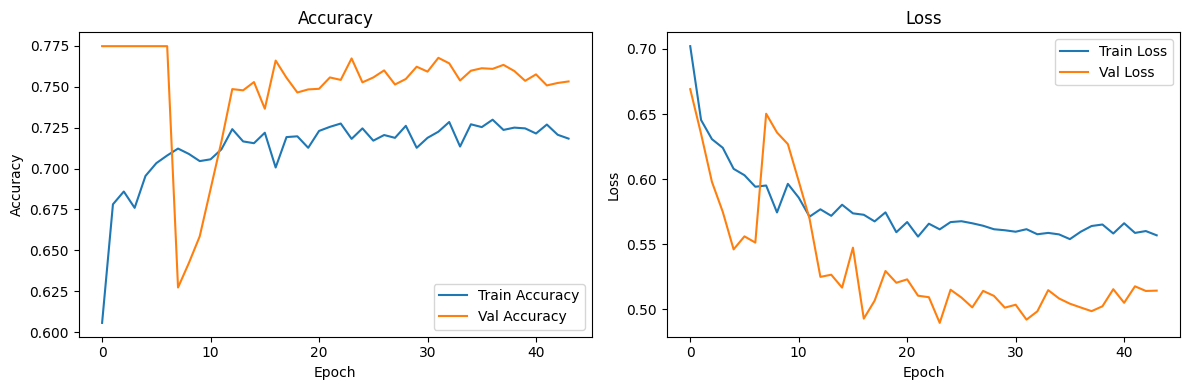

In [57]:
plt.figure(figsize=(12, 4))
 
plt.subplot(1, 2, 1)
plt.plot(hist.history["accuracy"],     label="Train Accuracy")
plt.plot(hist.history["val_accuracy"], label="Val Accuracy")
plt.title("Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
 
plt.subplot(1, 2, 2)
plt.plot(hist.history["loss"],     label="Train Loss")
plt.plot(hist.history["val_loss"], label="Val Loss")
plt.title("Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
 
plt.tight_layout()
plt.savefig("training_curves.png")
plt.show()


In [59]:
import numpy as np
from keras.models import load_model

saved_model = load_model("/kaggle/working/vgg16_pneumonia_best.keras")
testdata.reset()
preds = saved_model.predict(testdata)

predicted_classes = (preds > 0.5).astype(int).flatten()
true_classes = testdata.classes

from sklearn.metrics import classification_report, confusion_matrix
print(classification_report(true_classes, predicted_classes, 
      target_names=["Normal", "Pneumonia"]))
print(confusion_matrix(true_classes, predicted_classes))

42/42 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step
              precision    recall  f1-score   support

      Normal       0.91      0.78      0.84      4135
   Pneumonia       0.49      0.73      0.59      1202

    accuracy                           0.77      5337
   macro avg       0.70      0.75      0.71      5337
weighted avg       0.81      0.77      0.78      5337

[[3216  919]
 [ 323  879]]


In [58]:
from keras.preprocessing import image
from keras.models import load_model
 
def predict_xray(img_path, model_path="vgg16_pneumonia_best.h5"):
    saved_model = load_model("vgg16_pneumonia_best.keras")
    img = image.load_img(img_path, target_size=IMG_SIZE)
    img_array = np.expand_dims(np.asarray(img) / 255.0, axis=0)
    prob = saved_model.predict(img_array)[0][0]
    label = "PNEUMONIA" if prob > 0.5 else "NORMAL"
    print(f"Prediction : {label}  (confidence: {prob:.2f})")
    return label, prob